In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ===============================
# 1. 定义PINN网络
# ===============================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        self.activation = nn.Tanh()

    def forward(self, x):
        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))
        return self.layers[-1](x)

In [3]:
# ===============================
# 2. PDE残差
# ===============================
def pde_residual(model, x, t, nu):
    x.requires_grad = True
    t.requires_grad = True

    u = model(torch.cat([x, t], dim=1))

    u_t = torch.autograd.grad(u, t, torch.ones_like(u),
                             retain_graph=True, create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, torch.ones_like(u),
                             retain_graph=True, create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u),
                              retain_graph=True, create_graph=True)[0]

    f = u_t + u * u_x - nu * u_xx
    return f

In [4]:
# ===============================
# 3. 数据采样
# ===============================
def sample_uniform(N):
    x = np.linspace(-1, 1, int(np.sqrt(N)))
    t = np.linspace(0, 0.9, int(np.sqrt(N)))
    X, T = np.meshgrid(x, t)
    return X.flatten()[:, None], T.flatten()[:, None]

def sample_random(N):
    x = np.random.uniform(-1, 1, (N, 1))
    t = np.random.uniform(0, 0.9, (N, 1))
    return x, t

In [5]:
# ===============================
# 4. 初始 & 边界条件
# ===============================
def initial_condition(x):
    return -np.sin(np.pi * x)

def boundary_condition(t):
    return np.zeros_like(t)

In [ ]:
# ===============================
# 5. 训练函数
# ===============================
def train(model, epochs, N_f=10000, adaptive=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    nu = 0.01 / np.pi

    for epoch in range(epochs):

        # ====== 采样 ======
        if adaptive and epoch % 500 == 0 and epoch > 0:
            # 自适应加点
            x_rand, t_rand = sample_random(20000)
            x_r = torch.tensor(x_rand, dtype=torch.float32).to(device)
            t_r = torch.tensor(t_rand, dtype=torch.float32).to(device)

            f = pde_residual(model, x_r, t_r, nu).detach().cpu().numpy()
            idx = np.argsort(np.abs(f.flatten()))[-N_f:]
            x_f = x_rand[idx]
            t_f = t_rand[idx]

        else:
            # 均匀 or 随机
            x_f, t_f = sample_random(N_f)

        x_f = torch.tensor(x_f, dtype=torch.float32).to(device)
        t_f = torch.tensor(t_f, dtype=torch.float32).to(device)

        # ====== IC ======
        x_ic = np.random.uniform(-1, 1, (200, 1))
        t_ic = np.zeros_like(x_ic)
        u_ic = initial_condition(x_ic)

        x_ic = torch.tensor(x_ic, dtype=torch.float32).to(device)
        t_ic = torch.tensor(t_ic, dtype=torch.float32).to(device)
        u_ic = torch.tensor(u_ic, dtype=torch.float32).to(device)

        # ====== BC ======
        t_bc = np.random.uniform(0, 0.9, (200, 1))
        x_bc1 = -np.ones_like(t_bc)
        x_bc2 = np.ones_like(t_bc)

        u_bc = boundary_condition(t_bc)

        x_bc = np.vstack([x_bc1, x_bc2])
        t_bc = np.vstack([t_bc, t_bc])
        u_bc = np.vstack([u_bc, u_bc])

        x_bc = torch.tensor(x_bc, dtype=torch.float32).to(device)
        t_bc = torch.tensor(t_bc, dtype=torch.float32).to(device)
        u_bc = torch.tensor(u_bc, dtype=torch.float32).to(device)

        # ====== 计算损失 ======
        optimizer.zero_grad()

        # PDE
        f = pde_residual(model, x_f, t_f, nu)
        loss_f = torch.mean(f**2)

        # IC
        u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = torch.mean((u_pred_ic - u_ic)**2)

        # BC
        u_pred_bc = model(torch.cat([x_bc, t_bc], dim=1))
        loss_bc = torch.mean((u_pred_bc - u_bc)**2)

        loss = loss_f + loss_ic + loss_bc

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

In [7]:
# ===============================
# 6. 主函数
# ===============================
model = PINN([2, 50, 50, 50, 1]).to(device)

train(model, epochs=5000, adaptive=True)

d:\Software\Python\Python\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 0.515332
Epoch 500, Loss: 0.164216
Epoch 1000, Loss: 0.127780
Epoch 1500, Loss: 0.118567
Epoch 2000, Loss: 0.109958
Epoch 2500, Loss: 0.103568
Epoch 3000, Loss: 0.095469
Epoch 3500, Loss: 0.088137
Epoch 4000, Loss: 0.087495
Epoch 4500, Loss: 0.065562


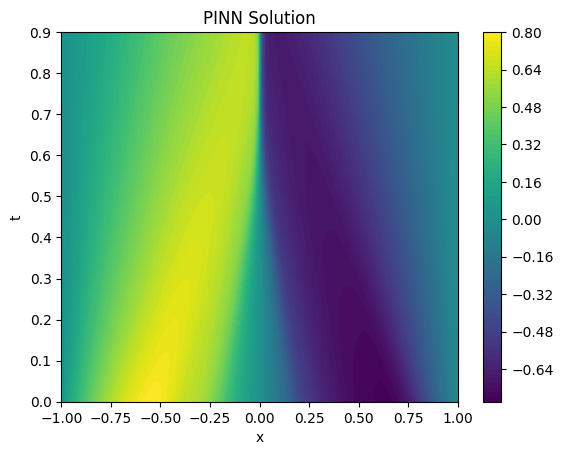

In [8]:
# ===============================
# 7. 可视化
# ===============================
x = np.linspace(-1, 1, 100)
t = np.linspace(0, 0.9, 100)
X, T = np.meshgrid(x, t)

XT = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
XT = torch.tensor(XT, dtype=torch.float32).to(device)

U = model(XT).detach().cpu().numpy()
U = U.reshape(100, 100)

plt.contourf(X, T, U, 100)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution")
plt.show()

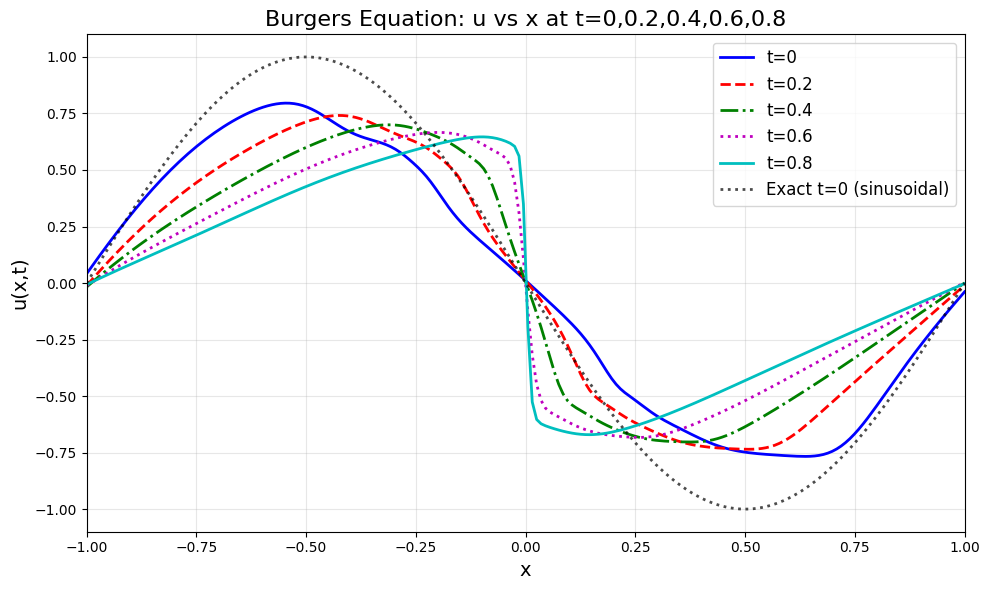

In [9]:
# ===============================
# 7. 可视化 - x与u在不同时间的图像
# ===============================
import matplotlib.pyplot as plt
# 生成x轴数据
x = np.linspace(-1, 1, 200)
x_tensor = torch.tensor(x[:, None], dtype=torch.float32).to(device)
# 定义要绘制的时间切片
time_slices = [0, 0.2, 0.4, 0.6, 0.8]
colors = ['b', 'r', 'g', 'm', 'c']  # 不同时间的颜色
line_styles = ['-', '--', '-.', ':', '-']
plt.figure(figsize=(10, 6))
for i, t_val in enumerate(time_slices):
    # 为当前时间切片创建输入数据
    t_vals = np.full_like(x, t_val)[:, None]
    XT_slice = np.hstack((x[:, None], t_vals))
    XT_tensor = torch.tensor(XT_slice, dtype=torch.float32).to(device)
    
    # 获取模型预测
    u_pred = model(XT_tensor).detach().cpu().numpy()
    
    # 绘制当前时间切片的曲线
    plt.plot(x, u_pred, 
             label=f't={t_val}', 
             color=colors[i],
             linestyle=line_styles[i],
             linewidth=2)
# 添加初始条件作为参考（t=0时的精确解）
u_initial = -np.sin(np.pi * x)
plt.plot(x, u_initial, 'k:', label='Exact t=0 (sinusoidal)', linewidth=2, alpha=0.7)
# 设置图形属性
plt.xlabel("x", fontsize=14)
plt.ylabel("u(x,t)", fontsize=14)
plt.title("Burgers Equation: u vs x at t=0,0.2,0.4,0.6,0.8", fontsize=16)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xlim([-1, 1])
plt.tight_layout()
plt.show()